# Modeling: NFL Run vs. Pass Prediction

**Predictive task.** Given the pre-snap state of an NFL play, predict whether the
offense will run (0) or pass (1). This is a binary classification problem on tabular
data.

**Why it matters.** Defenses spend a lot of effort anticipating play calls. A model
that reads only the public game state (down, distance, score, clock, field position,
betting lines) tells us how predictable NFL play-calling really is, and which
situations give away the most information.

**Evaluation.** We use a time-based split to avoid leakage and to simulate forecasting
a future season. We train on 2022 and 2023, select models on the 2024 validation
season, and keep 2025 untouched for the final test in `03_final_eval.ipynb`. For every
model we report accuracy, precision, recall, F1, and ROC-AUC, plus confusion matrices.
The number to beat is the majority-class baseline (always guess the more common class):
if teams pass about 58% of the time, a useful model has to clear 58%.

**Roadmap.**
1. Load and clean the data, engineer features (shared `src/features.py`).
2. Baselines: majority class, logistic regression (L2, then L1 vs L2), Gaussian Naive Bayes, linear SVM.
3. Advanced models: decision tree, random forest (bagging), LightGBM and XGBoost (boosting).
4. Model comparison across all five metrics.
5. Parameter sensitivity (validation curves) and a cross-validated grid search.
6. Ablation study: do pre-snap formation cues (`shotgun`, `no_huddle`) help?
7. Feature importance and a PCA view of the feature space.
8. Save the best model for the demo app and the final evaluation.

Each modeling choice ties back to a course lecture (OLS/Logistic, Regularization, SVM,
Naive Bayes/Decision Trees, Ensembles, PCA).

## 1. Setup, Data and Features

In [31]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# the shared feature module lives at the repo root (parent of notebooks/)
sys.path.insert(0, os.path.abspath(".."))
from src import features as F

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.decomposition import PCA
import lightgbm as lgb
import xgboost as xgb
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded. LightGBM", lgb.__version__, "| XGBoost", xgb.__version__)

Libraries loaded. LightGBM 4.6.0 | XGBoost 3.2.0


In [32]:
DATA = "../data"
train_paths = [f"{DATA}/train/play_by_play_{y}.parquet" for y in (2022, 2023, 2024)]
raw = F.load_seasons(train_paths)
print(f"Raw run/pass plays (2022-2024): {len(raw):,}")

# build_xy with formation returns situation + formation columns; we slice as needed
X_all, y, season = F.build_xy(raw, include_formation=True)
print(f"After cleaning: {len(X_all):,} plays | pass rate = {y.mean():.3f}")
print(f"situation features = {len(F.SITUATION_FEATURES)} | full features = {len(F.FULL_FEATURES)}")
X_all.head()

Raw run/pass plays (2022-2024): 106,080
After cleaning: 105,681 plays | pass rate = 0.576
situation features = 29 | full features = 31


,down_1,down_2,down_3,down_4,ydstogo,yardline_100,score_differential,qtr,half_seconds_remaining,game_seconds_remaining,...,third_and_long,third_and_short,red_zone,trailing,leading,trailing_late,leading_late,score_time_pressure,shotgun,no_huddle
2,1,0,0,0,10.0,78.0,0.0,1.0,1796.0,3596.0,...,0,0,0,0,0,0,0,0.0,0,0
3,1,0,0,0,10.0,59.0,0.0,1.0,1769.0,3569.0,...,0,0,0,0,0,0,0,0.0,1,1
4,0,1,0,0,10.0,59.0,0.0,1.0,1765.0,3565.0,...,0,0,0,0,0,0,0,0.0,0,1
5,0,0,1,0,5.0,54.0,0.0,1.0,1741.0,3541.0,...,0,0,0,0,0,0,0,0.0,1,1
7,1,0,0,0,10.0,72.0,0.0,1.0,1722.0,3522.0,...,0,0,0,0,0,0,0,0.0,0,0


### Time-based train/validation split

We train on 2022-2023 and validate on 2024. A random split would let the model peek at
the same games' tendencies; splitting forward in time is the honest test of whether the
model generalizes to a future season, which is how it would actually be used. The 2025
season is never touched here.

In [33]:
tr_mask = season.isin([2022, 2023]).values
va_mask = (season == 2024).values

sit = F.SITUATION_FEATURES
Xtr, Xva = X_all.loc[tr_mask, sit], X_all.loc[va_mask, sit]
ytr, yva = y[tr_mask], y[va_mask]

print(f"Train: {Xtr.shape[0]:,} plays (2022-23) | pass rate {ytr.mean():.3f}")
print(f"Valid: {Xva.shape[0]:,} plays (2024)    | pass rate {yva.mean():.3f}")

Train: 70,778 plays (2022-23) | pass rate 0.578
Valid: 34,903 plays (2024)    | pass rate 0.570


### Evaluation helper

A single function computes the full metric suite for each model so the final comparison
is apples to apples.

In [34]:
results = []

def evaluate(name, y_true, y_pred, y_score, note=""):
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "Note": note,
    }
    results.append(row)
    print(f"{name:<26s} acc={row['Accuracy']:.4f}  prec={row['Precision']:.4f}  "
          f"rec={row['Recall']:.4f}  F1={row['F1']:.4f}  AUC={row['ROC-AUC']:.4f}")
    return row

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=["run", "pass"], yticklabels=["run", "pass"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.tight_layout(); plt.show()

## 2. Baselines

We start simple so every later model has something to beat. Each baseline maps to a
method from class.

### 2.0 Majority-class baseline

The simplest reasonable model: always predict the most frequent training class (pass).
Its accuracy is just the validation pass rate, and its scores carry no information, so
its ROC-AUC is 0.5.

In [35]:
majority_class = int(round(ytr.mean()))
maj_pred = np.full_like(yva, majority_class)
maj_score = np.full(len(yva), ytr.mean())   # constant score -> AUC 0.5
evaluate("Majority (always pass)", yva, maj_pred, maj_score, note="naive baseline")

Majority (always pass)     acc=0.5701  prec=0.5701  rec=1.0000  F1=0.7262  AUC=0.5000


{'Model': 'Majority (always pass)',
 'Accuracy': 0.5700656104059822,
 'Precision': 0.5700656104059822,
 'Recall': 1.0,
 'F1': 0.7261678832116788,
 'ROC-AUC': 0.5,
 'Note': 'naive baseline'}

### 2.1 Logistic Regression (Lecture 1)

The canonical linear classifier: a sigmoid over a weighted sum of features. Linear
models need features on comparable scales, so we put a `StandardScaler` and the
classifier in a `Pipeline`.

Logistic Regression (L2)   acc=0.6767  prec=0.7066  rec=0.7402  F1=0.7230  AUC=0.7385


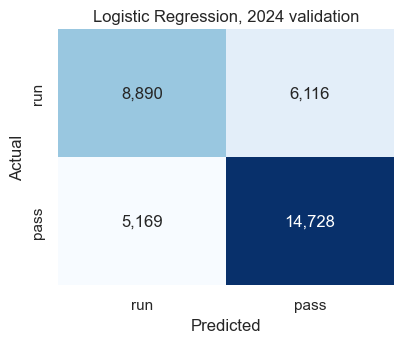

In [36]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
])
logreg.fit(Xtr, ytr)
pred = logreg.predict(Xva)
score = logreg.predict_proba(Xva)[:, 1]
evaluate("Logistic Regression (L2)", yva, pred, score, note="C=1.0, scaled")
plot_confusion(yva, pred, "Logistic Regression, 2024 validation")

### 2.2 Regularization: L1 vs L2 (Lecture 2)

Lecture 2 contrasts Ridge (L2), which shrinks all weights toward zero, with Lasso (L1),
which drives some weights exactly to zero and so performs feature selection. We fit both
at the same strength and compare validation accuracy and how many coefficients L1 zeroes
out.

penalty  val_accuracy  coeffs_zeroed  of_total
     L2      0.676675              0        29
     L1      0.676647              0        29


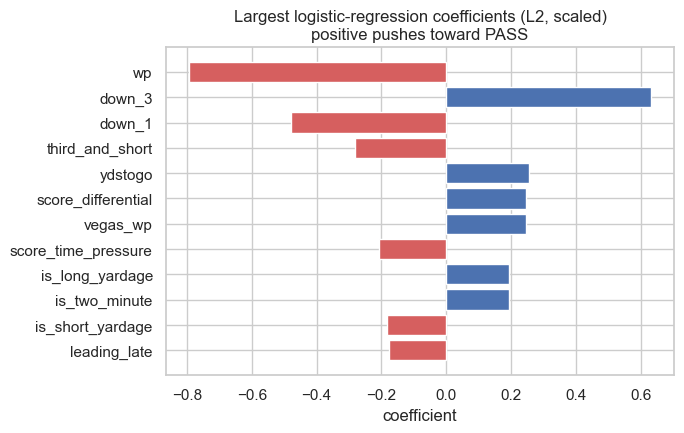

In [37]:
reg_rows = []
coef_table = pd.DataFrame({"feature": sit})
for pen, solver in [("l2", "lbfgs"), ("l1", "liblinear")]:
    m = Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(penalty=pen, solver=solver,
                                             C=1.0, max_iter=4000,
                                             random_state=RANDOM_STATE))]).fit(Xtr, ytr)
    coefs = m.named_steps["clf"].coef_.ravel()
    reg_rows.append({"penalty": pen.upper(),
                     "val_accuracy": accuracy_score(yva, m.predict(Xva)),
                     "coeffs_zeroed": int(np.sum(np.abs(coefs) < 1e-6)),
                     "of_total": len(coefs)})
    coef_table[pen.upper()] = coefs

print(pd.DataFrame(reg_rows).to_string(index=False))

# strongest L2 coefficients show the direction of each effect on pass probability
top = coef_table.reindex(coef_table["L2"].abs().sort_values(ascending=False).index).head(12)
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#d65f5f" if v < 0 else "#4c72b0" for v in top["L2"]]
ax.barh(top["feature"][::-1], top["L2"][::-1], color=colors[::-1])
ax.set_title("Largest logistic-regression coefficients (L2, scaled)\npositive pushes toward PASS")
ax.set_xlabel("coefficient"); plt.tight_layout(); plt.show()

### 2.3 Gaussian Naive Bayes (Lecture 4)

Naive Bayes assumes features are conditionally independent given the class and, in the
Gaussian variant, that each numeric feature is normally distributed within a class. That
independence assumption is clearly false here (down, distance, and win probability are
correlated), so we expect Naive Bayes to trail logistic regression, which is a good
illustration of the lecture's caveat.

In [38]:
nb = GaussianNB().fit(Xtr, ytr)
pred = nb.predict(Xva)
score = nb.predict_proba(Xva)[:, 1]
evaluate("Gaussian Naive Bayes", yva, pred, score, note="independence assumption")

Gaussian Naive Bayes       acc=0.6392  prec=0.7140  rec=0.6125  F1=0.6594  AUC=0.7023


{'Model': 'Gaussian Naive Bayes',
 'Accuracy': 0.6392287195943042,
 'Precision': 0.7139844161930986,
 'Recall': 0.6125043976478867,
 'F1': 0.6593626575772331,
 'ROC-AUC': 0.702256848345415,
 'Note': 'independence assumption'}

### 2.4 Linear SVM (Lecture 3)

A max-margin linear classifier with hinge loss. We use `LinearSVC` (liblinear), which
scales to 100k rows far better than a kernel SVM. `LinearSVC` has no `predict_proba`, so
we wrap it in `CalibratedClassifierCV` to recover scores for ROC-AUC.

In [39]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=1.0, dual=False,
                                             random_state=RANDOM_STATE), cv=3)),
]).fit(Xtr, ytr)
pred = svm.predict(Xva)
score = svm.predict_proba(Xva)[:, 1]
evaluate("Linear SVM", yva, pred, score, note="hinge loss, scaled")

Linear SVM                 acc=0.6751  prec=0.7024  rec=0.7464  F1=0.7237  AUC=0.7372


{'Model': 'Linear SVM',
 'Accuracy': 0.6751282124745723,
 'Precision': 0.702374195989406,
 'Recall': 0.7463939287329748,
 'F1': 0.7237153090811628,
 'ROC-AUC': 0.7372387209697047,
 'Note': 'hinge loss, scaled'}

## 3. Advanced Models

NFL play-calling is full of interactions (for example, 3rd-and-long while trailing late)
and non-linear thresholds that linear models capture only through hand-built features.
Tree-based models learn these automatically, which is why we expect them to win.

### 3.1 Decision Tree (Lecture 4)

A single greedy tree with Gini splits. On its own it overfits if grown unbounded, so we
cap the depth. It is the building block for the ensembles that follow.

In [40]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                            random_state=RANDOM_STATE).fit(Xtr, ytr)
pred = dt.predict(Xva)
score = dt.predict_proba(Xva)[:, 1]
evaluate("Decision Tree", yva, pred, score, note="max_depth=8")

Decision Tree              acc=0.6905  prec=0.7681  rec=0.6547  F1=0.7069  AUC=0.7506


{'Model': 'Decision Tree',
 'Accuracy': 0.6904850585909521,
 'Precision': 0.7681014150943396,
 'Recall': 0.6547218173594009,
 'F1': 0.7068942127682666,
 'ROC-AUC': 0.7506085970898868,
 'Note': 'max_depth=8'}

### 3.2 Random Forest, bagging (Lecture 5)

Bagging trains many trees on bootstrap samples with random feature subsets and averages
them, which reduces variance. It is robust out of the box on tabular data.

Random Forest              acc=0.6975  prec=0.7466  rec=0.7106  F1=0.7281  AUC=0.7637


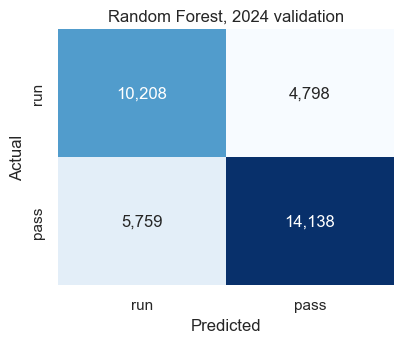

In [41]:
rf = RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
                            n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
pred = rf.predict(Xva)
score = rf.predict_proba(Xva)[:, 1]
evaluate("Random Forest", yva, pred, score, note="300 trees, depth 14")
plot_confusion(yva, pred, "Random Forest, 2024 validation")

### 3.3 LightGBM, boosting (Lecture 5)

Boosting builds trees sequentially, each one correcting the previous ensemble's errors,
which reduces bias. AdaBoost is the lecture example; gradient boosting is its modern
descendant. LightGBM is a fast histogram-based implementation that grows trees leaf-wise
and is usually strong on tabular sports data.

LightGBM                   acc=0.6942  prec=0.7331  rec=0.7292  F1=0.7311  AUC=0.7641


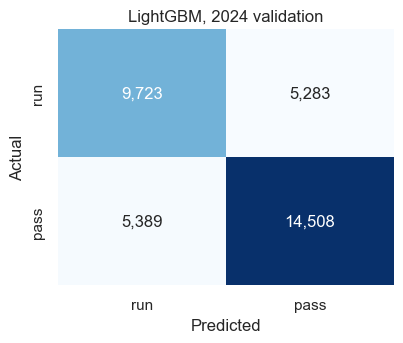

In [42]:
lgbm = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm.fit(Xtr, ytr)
pred = lgbm.predict(Xva)
score = lgbm.predict_proba(Xva)[:, 1]
evaluate("LightGBM", yva, pred, score, note="600 trees, lr=0.05")
plot_confusion(yva, pred, "LightGBM, 2024 validation")

### 3.4 XGBoost, boosting (Lecture 5)

XGBoost is the other widely used gradient-boosting library. It belongs to the same family
as LightGBM but grows trees level-wise by default rather than leaf-wise, so it tunes a
little differently. Including both lets us check whether the choice of boosting library
actually matters for this task. We use the histogram tree method for speed.

In [43]:
xgbst = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, tree_method="hist",
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
)
xgbst.fit(Xtr, ytr)
pred = xgbst.predict(Xva)
score = xgbst.predict_proba(Xva)[:, 1]
evaluate("XGBoost", yva, pred, score, note="600 trees, depth 6")

XGBoost                    acc=0.6938  prec=0.7297  rec=0.7353  F1=0.7325  AUC=0.7628


{'Model': 'XGBoost',
 'Accuracy': 0.6938085551385268,
 'Precision': 0.7296758104738155,
 'Recall': 0.7352867266422074,
 'F1': 0.7324705234435627,
 'ROC-AUC': 0.7627542003921823,
 'Note': '600 trees, depth 6'}

## 4. Model Comparison

All five metrics for every model on the 2024 validation season.

In [44]:
res_df = (pd.DataFrame(results)
          .drop_duplicates(subset="Model", keep="last")
          .sort_values("Accuracy", ascending=False)
          .reset_index(drop=True))
baseline_acc = yva.mean()
print(f"Majority-class baseline accuracy = {baseline_acc:.4f}\n")
res_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Note"]].round(4)

Majority-class baseline accuracy = 0.5701



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Note
0,Random Forest,0.6975,0.7466,0.7106,0.7281,0.7637,"300 trees, depth 14"
1,LightGBM,0.6942,0.7331,0.7292,0.7311,0.7641,"600 trees, lr=0.05"
2,XGBoost,0.6938,0.7297,0.7353,0.7325,0.7628,"600 trees, depth 6"
3,Decision Tree,0.6905,0.7681,0.6547,0.7069,0.7506,max_depth=8
4,Logistic Regression (L2),0.6767,0.7066,0.7402,0.7230,0.7385,"C=1.0, scaled"
5,Linear SVM,0.6751,0.7024,0.7464,0.7237,0.7372,"hinge loss, scaled"
6,Gaussian Naive Bayes,0.6392,0.7140,0.6125,0.6594,0.7023,independence assumption
7,Majority (always pass),0.5701,0.5701,1.0000,0.7262,0.5000,naive baseline


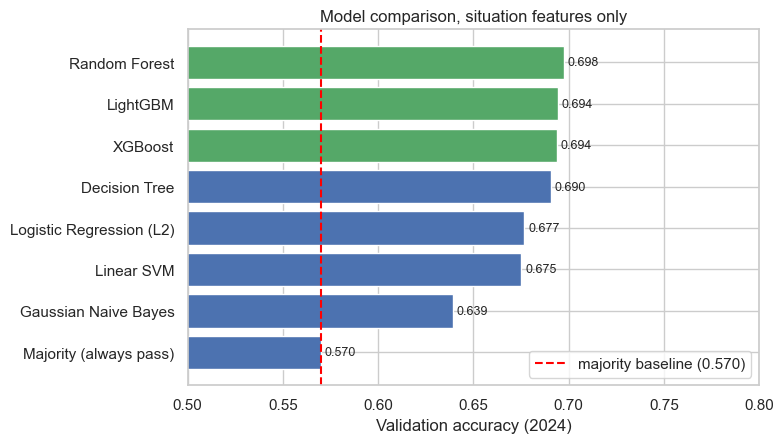

In [45]:
fig, ax = plt.subplots(figsize=(8, 4.6))
order = res_df.sort_values("Accuracy")
colors = ["#55a868" if m in ("Random Forest", "LightGBM", "XGBoost") else "#4c72b0"
          for m in order["Model"]]
ax.barh(order["Model"], order["Accuracy"], color=colors)
ax.axvline(baseline_acc, color="red", ls="--", lw=1.5,
           label=f"majority baseline ({baseline_acc:.3f})")
ax.set_xlim(0.5, max(0.8, order["Accuracy"].max() + 0.03))
ax.set_xlabel("Validation accuracy (2024)")
ax.set_title("Model comparison, situation features only")
for y_, v in zip(range(len(order)), order["Accuracy"]):
    ax.text(v + 0.002, y_, f"{v:.3f}", va="center", fontsize=9)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 5. Parameter Sensitivity

We sweep one hyper-parameter at a time and plot train versus validation accuracy. The
gap between the curves is the bias-variance story from Lecture 5: when train accuracy
keeps rising while validation flattens or falls, the model is overfitting.

### 5.1 Logistic Regression: regularization strength C (Lecture 2)

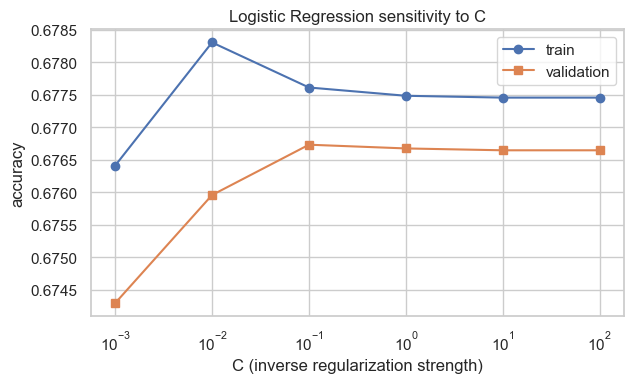

Best C: 0.1 -> val acc 0.6767


In [46]:
C_grid = [0.001, 0.01, 0.1, 1, 10, 100]
tr_acc, va_acc = [], []
for C in C_grid:
    m = Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(C=C, max_iter=4000,
                                             random_state=RANDOM_STATE))]).fit(Xtr, ytr)
    tr_acc.append(accuracy_score(ytr, m.predict(Xtr)))
    va_acc.append(accuracy_score(yva, m.predict(Xva)))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(C_grid, tr_acc, "o-", label="train")
ax.semilogx(C_grid, va_acc, "s-", label="validation")
ax.set_xlabel("C (inverse regularization strength)"); ax.set_ylabel("accuracy")
ax.set_title("Logistic Regression sensitivity to C"); ax.legend(); plt.tight_layout(); plt.show()
print("Best C:", C_grid[int(np.argmax(va_acc))], "-> val acc", round(max(va_acc), 4))

### 5.2 Random Forest: max_depth and n_estimators (Lecture 5)

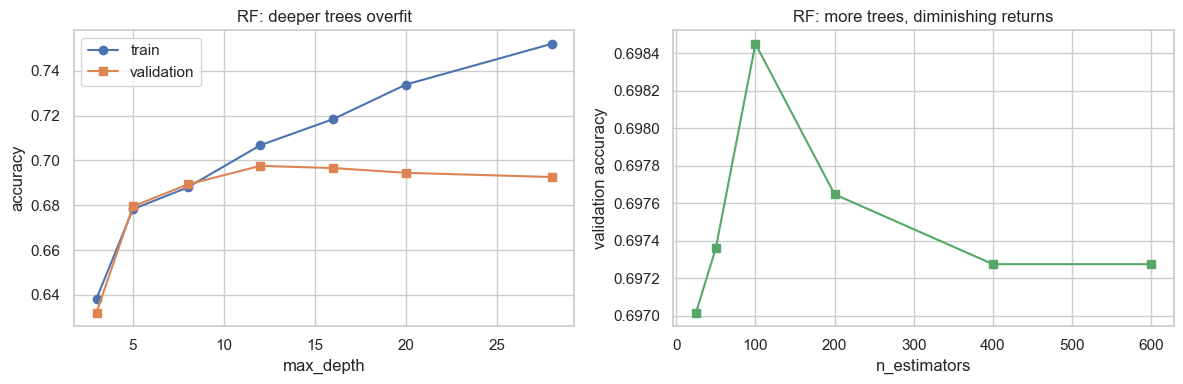

Best depth: 12 -> val acc 0.6976


In [47]:
depth_grid = [3, 5, 8, 12, 16, 20, 28]
tr_acc, va_acc = [], []
for d in depth_grid:
    m = RandomForestClassifier(n_estimators=200, max_depth=d, min_samples_leaf=20,
                               n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
    tr_acc.append(accuracy_score(ytr, m.predict(Xtr)))
    va_acc.append(accuracy_score(yva, m.predict(Xva)))

n_grid = [25, 50, 100, 200, 400, 600]
n_va = []
for n in n_grid:
    m = RandomForestClassifier(n_estimators=n, max_depth=14, min_samples_leaf=20,
                               n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
    n_va.append(accuracy_score(yva, m.predict(Xva)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(depth_grid, tr_acc, "o-", label="train")
axes[0].plot(depth_grid, va_acc, "s-", label="validation")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("accuracy")
axes[0].set_title("RF: deeper trees overfit"); axes[0].legend()
axes[1].plot(n_grid, n_va, "s-", color="#55a868")
axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("validation accuracy")
axes[1].set_title("RF: more trees, diminishing returns")
plt.tight_layout(); plt.show()
print("Best depth:", depth_grid[int(np.argmax(va_acc))], "-> val acc", round(max(va_acc), 4))

### 5.3 LightGBM: learning_rate and num_leaves (Lecture 5)

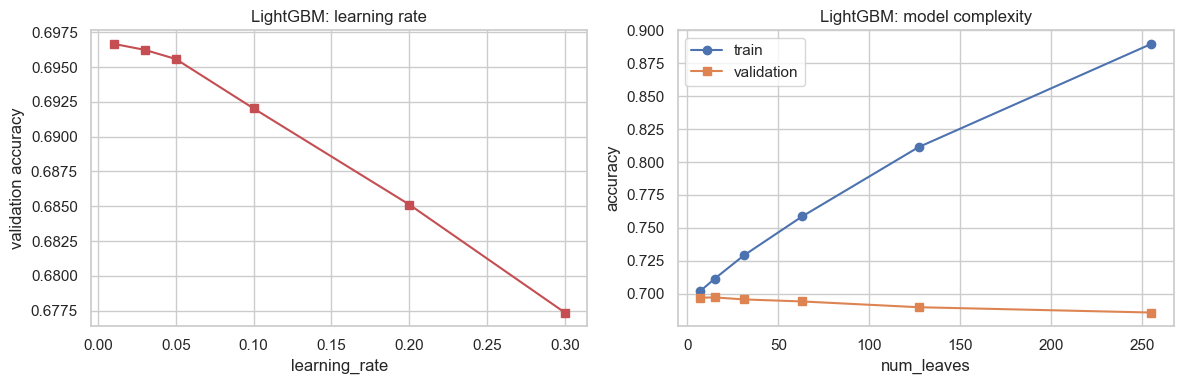

Best lr: 0.01 -> val acc 0.6967


In [48]:
lr_grid = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]
lr_va = []
for lr in lr_grid:
    m = lgb.LGBMClassifier(n_estimators=400, learning_rate=lr, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(Xtr, ytr)
    lr_va.append(accuracy_score(yva, m.predict(Xva)))

leaf_grid = [7, 15, 31, 63, 127, 255]
leaf_tr, leaf_va = [], []
for nl in leaf_grid:
    m = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=nl,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(Xtr, ytr)
    leaf_tr.append(accuracy_score(ytr, m.predict(Xtr)))
    leaf_va.append(accuracy_score(yva, m.predict(Xva)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lr_grid, lr_va, "s-", color="#c44e52")
axes[0].set_xlabel("learning_rate"); axes[0].set_ylabel("validation accuracy")
axes[0].set_title("LightGBM: learning rate")
axes[1].plot(leaf_grid, leaf_tr, "o-", label="train")
axes[1].plot(leaf_grid, leaf_va, "s-", label="validation")
axes[1].set_xlabel("num_leaves"); axes[1].set_ylabel("accuracy")
axes[1].set_title("LightGBM: model complexity"); axes[1].legend()
plt.tight_layout(); plt.show()
print("Best lr:", lr_grid[int(np.argmax(lr_va))], "-> val acc", round(max(lr_va), 4))

### 5.4 Cross-validated grid search on LightGBM

The sweeps above tune one knob at a time on a single split. Here we run a 5-fold
cross-validated grid search over the main LightGBM knobs to pick a final configuration.

In [49]:
param_grid = {
    "n_estimators": [400, 800],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63],
    "min_child_samples": [20, 50],
}
base = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(base, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=0)
t0 = time.time(); gs.fit(Xtr, ytr)
print(f"GridSearchCV done in {time.time()-t0:.1f}s over {len(gs.cv_results_['params'])} configs")
print("Best CV accuracy:", round(gs.best_score_, 4))
print("Best params:", gs.best_params_)
best_lgbm = gs.best_estimator_
va_pred = best_lgbm.predict(Xva); va_score = best_lgbm.predict_proba(Xva)[:, 1]
evaluate("LightGBM (tuned)", yva, va_pred, va_score, note="5-fold GridSearchCV")

GridSearchCV done in 271.0s over 16 configs
Best CV accuracy: 0.6968
Best params: {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 400, 'num_leaves': 31}
LightGBM (tuned)           acc=0.6962  prec=0.7362  rec=0.7278  F1=0.7320  AUC=0.7664


{'Model': 'LightGBM (tuned)',
 'Accuracy': 0.6961579233876745,
 'Precision': 0.736173241154941,
 'Recall': 0.7278484193597025,
 'F1': 0.7319871616669615,
 'ROC-AUC': 0.7663748877825693,
 'Note': '5-fold GridSearchCV'}

## 6. Ablation Study: do pre-snap formation cues help?

Every model so far used situation features only. The data also exposes pre-snap formation
cues, `shotgun` and `no_huddle`, which a defender sees once the offense lines up. They are
legitimate (known before the snap) but very informative: in our data teams pass 69% of the
time from shotgun versus 30% otherwise.

The ablation re-trains the same models on situation plus formation features and reports
all five metrics for both feature sets, so we can see exactly what the two cues are worth.

In [ ]:
Xtr_full = X_all.loc[tr_mask, F.FULL_FEATURES]
Xva_full = X_all.loc[va_mask, F.FULL_FEATURES]

def make_model(name):
    if name == "Logistic Regression":
        return Pipeline([("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))])
    if name == "Random Forest":
        return RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
            n_jobs=-1, random_state=RANDOM_STATE)
    if name == "LightGBM":
        return lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    if name == "XGBoost":
        return xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, tree_method="hist", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

def metric_dict(y_true, y_pred, y_score):
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_score)}

abl = []
feature_sets = {"situation": (Xtr, Xva), "situation + formation": (Xtr_full, Xva_full)}
for name in ["Logistic Regression", "Random Forest", "LightGBM", "XGBoost"]:
    for label, (Xt, Xv) in feature_sets.items():
        m = make_model(name).fit(Xt, ytr)
        row = {"Model": name, "Features": label}
        row.update(metric_dict(yva, m.predict(Xv), m.predict_proba(Xv)[:, 1]))
        abl.append(row)
abl_df = pd.DataFrame(abl)
abl_df.round(4)

In [ ]:
# accuracy lift from adding the two formation cues
pivot = abl_df.pivot(index="Model", columns="Features", values="Accuracy")
pivot["Lift"] = pivot["situation + formation"] - pivot["situation"]
print(pivot.round(4).to_string())

models = pivot.index.tolist()
x = np.arange(len(models)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - w/2, pivot["situation"], w, label="situation only", color="#4c72b0")
ax.bar(x + w/2, pivot["situation + formation"], w, label="plus formation", color="#dd8452")
ax.axhline(baseline_acc, color="red", ls="--", lw=1, label=f"baseline ({baseline_acc:.3f})")
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0.55, 0.85)
ax.set_ylabel("validation accuracy")
ax.set_title("Ablation: pre-snap formation cues add a consistent lift")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Interpretation

### 7.1 Feature importance

Which variables drive the predictions? We read gain-based importances from a LightGBM fit
on the full feature set.

In [ ]:
imp_model = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1).fit(Xtr_full, ytr)
imp = (pd.DataFrame({"feature": F.FULL_FEATURES, "importance": imp_model.feature_importances_})
       .sort_values("importance", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.barplot(data=imp, y="feature", x="importance", color="#4c72b0", ax=ax)
ax.set_title("LightGBM feature importance (top 15, gain)"); plt.tight_layout(); plt.show()
imp.reset_index(drop=True)

### 7.2 PCA view of the feature space (Lecture 9)

PCA is unsupervised, but projecting the standardized situation features onto their first
two principal components shows how separable run and pass plays are linearly. Heavy
overlap here is the reason non-linear tree ensembles beat the linear baselines.

In [ ]:
samp = np.random.RandomState(RANDOM_STATE).choice(len(Xtr), size=6000, replace=False)
Xs = StandardScaler().fit_transform(Xtr.iloc[samp])
pcs = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xs)
Z = pcs.transform(Xs)
fig, ax = plt.subplots(figsize=(6.5, 5))
for cls, color, lab in [(0, "#55a868", "run"), (1, "#c44e52", "pass")]:
    m = ytr.iloc[samp].values == cls
    ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.3, c=color, label=lab)
ax.set_xlabel(f"PC1 ({pcs.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pcs.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA of situation features (run vs pass overlap)"); ax.legend()
plt.tight_layout(); plt.show()
print("Variance explained by first 2 PCs:", round(pcs.explained_variance_ratio_[:2].sum(), 3))

## 8. Save the Best Model

We refit the tuned LightGBM on all of 2022-2024 using the full feature set and save it for
two consumers: `03_final_eval.ipynb` (the 2025 test) and `demo/app.py` (the interactive
demo). We store the model, the exact feature ordering, and the tuned hyper-parameters so
the artifact is reproducible.

In [ ]:
os.makedirs("../models", exist_ok=True)

final_params = dict(gs.best_params_)
final_model = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **final_params)
X_full_all = X_all[F.FULL_FEATURES]
final_model.fit(X_full_all, y)

artifact = {
    "model": final_model,
    "features": F.FULL_FEATURES,
    "situation_features": F.SITUATION_FEATURES,
    "formation_features": F.FORMATION_FEATURES,
    "params": final_params,
    "train_seasons": [2022, 2023, 2024],
    "baseline_pass_rate": float(y.mean()),
}
joblib.dump(artifact, "../models/lgbm_runpass.joblib")
print("Saved -> models/lgbm_runpass.joblib")
print("Refit on", len(X_full_all), "plays with", len(F.FULL_FEATURES), "features.")

## 9. Takeaways

Everything beats the 58% majority baseline. Even logistic regression on pure game-state
features lands well above it, so NFL play-calling is genuinely predictable from public
context.

Tree ensembles win. Random forest (bagging, lower variance) and the two boosting libraries
(LightGBM and XGBoost, lower bias) top the linear baselines because play-calling hinges on
feature interactions that linear models capture only through hand-built terms. LightGBM and
XGBoost finish within a fraction of a point of each other, which matches the general finding
that on tabular data the choice of boosting library rarely matters once both are tuned.

Naive Bayes lags, exactly as Lecture 4 predicts, because its conditional-independence
assumption is false for these correlated game-state features.

Parameter sensitivity shows the bias-variance trade-off directly: deep trees and large
num_leaves overfit (train accuracy far above validation), and regularization (C, learning
rate) controls it.

Pre-snap formation cues are decisive. The ablation shows `shotgun` and `no_huddle` add a
consistent accuracy lift across every model, the single most valuable signal a defense can
read before the snap.

The tuned LightGBM is saved for the 2025 final evaluation and the interactive demo.